# MIMIC-IV Microbiology Exploration

This notebook performs EDA specifically on the `microbiologyevents` table to understand data sparsity, test frequencies, and the relationship between specimen types and tests. It also maps the specimens into 7 clinical panels for the P-CAFE Reinforcement Learning environment.

## Section 1: Setup & Data Loading

In [4]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better readability
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11

# Define base path to MIMIC-IV data
#base_path = 'C:\\Users\\Eli\\Data\\physionet.org\\files\\mimiciv\\3.1\\hosp\\'
base_path = '~/data/physionet.org/files/mimiciv/3.1/hosp/'  # Base path to MIMIC-IV data


# Load microbiology events
print("Loading microbiologyevents.csv.gz ...")
#micro_df = pd.read_csv(base_path + 'microbiologyevents.csv.gz')
micro_df = pd.read_csv(
    base_path + 'microbiologyevents.csv.gz',
    dtype={'quantity': 'string'},   # keep raw values safely
    low_memory=False                # avoid mixed-type warning from chunk inference
)
print(f"Loaded microbiologyevents: {micro_df.shape[0]:,} rows, {micro_df.shape[1]} columns")

# Load admissions to get total unique hadm_ids
print("Loading admissions.csv.gz ...")
adm_df = pd.read_csv(base_path + 'admissions.csv.gz')
total_admissions = adm_df['hadm_id'].nunique()
print(f"Total unique hospital admissions (hadm_id): {total_admissions:,}")

# Filter out rows where hadm_id is null (events not linked to an admission)
micro_df = micro_df.dropna(subset=['hadm_id'])
print(f"After dropping null hadm_id: {micro_df.shape[0]:,} rows remain")
print("\nColumn overview:")
print(micro_df.dtypes)

Loading microbiologyevents.csv.gz ...
Loaded microbiologyevents: 3,988,224 rows, 25 columns
Loading admissions.csv.gz ...
Total unique hospital admissions (hadm_id): 546,028
After dropping null hadm_id: 1,759,881 rows remain

Column overview:
microevent_id            int64
subject_id               int64
hadm_id                float64
micro_specimen_id        int64
order_provider_id          str
chartdate                  str
charttime                  str
spec_itemid              int64
spec_type_desc             str
test_seq                 int64
storedate                  str
storetime                  str
test_itemid              int64
test_name                  str
org_itemid             float64
org_name                   str
isolate_num            float64
quantity                string
ab_itemid              float64
ab_name                    str
dilution_text              str
dilution_comparison        str
dilution_value         float64
interpretation             str
comments     

## Section 2: Relation of `spec_type_desc` to `test_name`

Unique test_names per spec_type_desc:
spec_type_desc
SWAB                                                        57
TISSUE                                                      36
FLUID,OTHER                                                 34
ASPIRATE                                                    29
STOOL                                                       29
SEROLOGY/BLOOD                                              27
BRONCHOALVEOLAR LAVAGE                                      26
BRONCHIAL WASHINGS                                          22
URINE                                                       21
PLEURAL FLUID                                               21
PERITONEAL FLUID                                            21
ABSCESS                                                     21
BIOPSY                                                      19
SPUTUM                                                      19
CSF;SPINAL FLUID                                            18
Mi

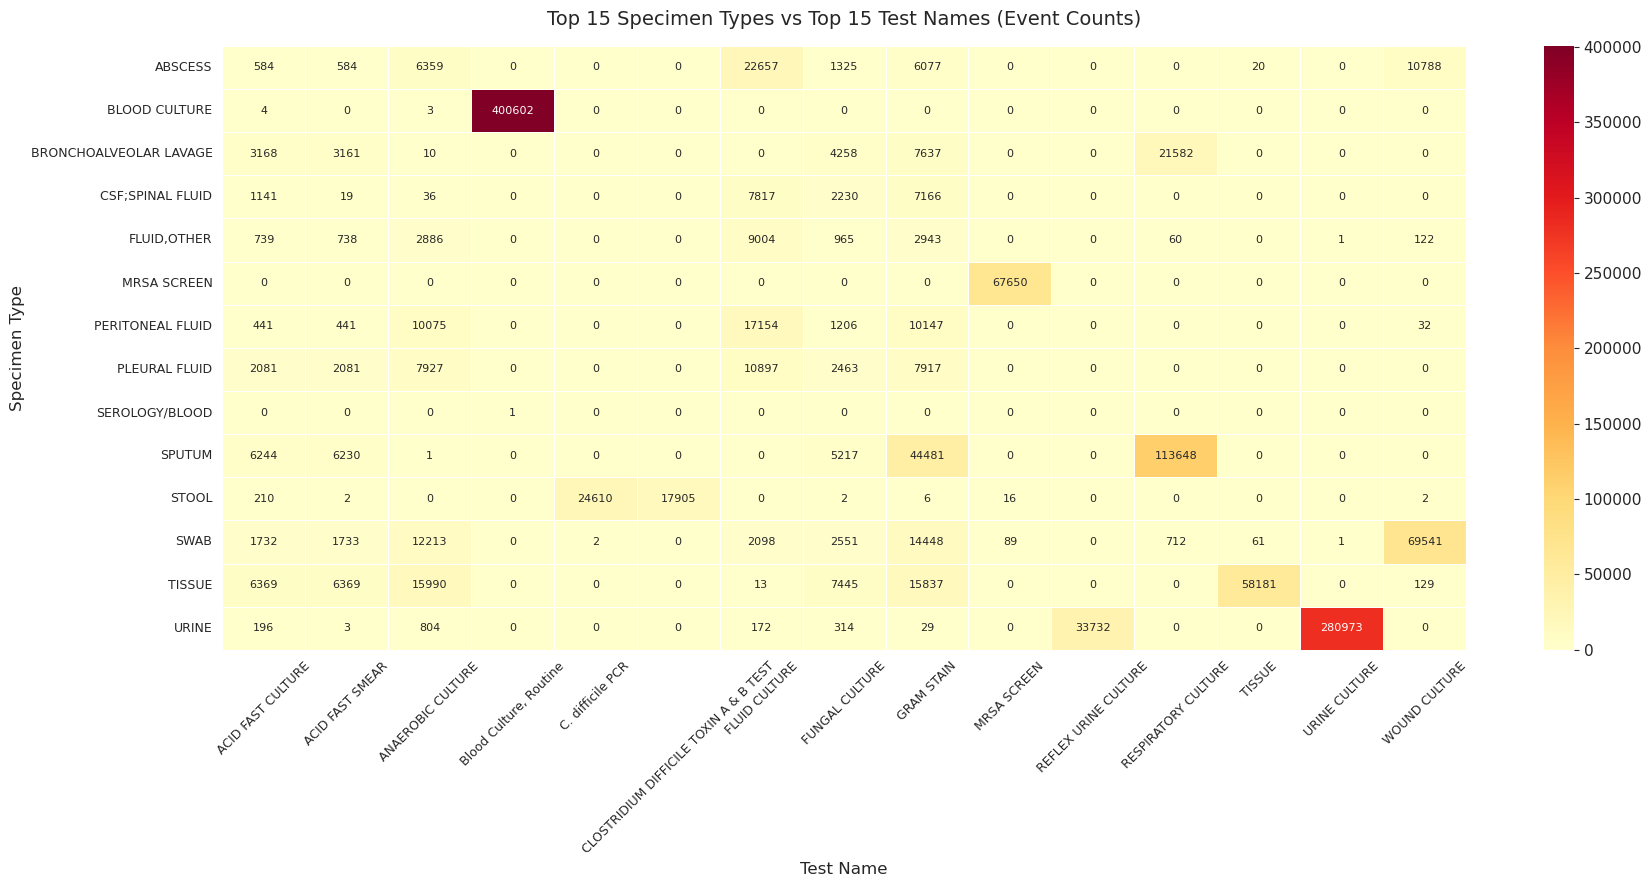

In [5]:
# --- Unique test_names per spec_type_desc ---
tests_per_spec = (
    micro_df.groupby('spec_type_desc')['test_name']
    .nunique()
    .sort_values(ascending=False)
)
print("Unique test_names per spec_type_desc:")
print(tests_per_spec.to_string())
print(f"\nTotal unique spec_type_desc values: {tests_per_spec.shape[0]}")

# --- Cross-tabulation: Top 15 spec_type_desc vs Top 15 test_name ---
top15_spec = micro_df['spec_type_desc'].value_counts().head(15).index.tolist()
top15_test = micro_df['test_name'].value_counts().head(15).index.tolist()

cross_tab = (
    micro_df[
        micro_df['spec_type_desc'].isin(top15_spec) &
        micro_df['test_name'].isin(top15_test)
    ]
    .pivot_table(
        index='spec_type_desc',
        columns='test_name',
        aggfunc='size',
        fill_value=0
    )
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 9))
sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Top 15 Specimen Types vs Top 15 Test Names (Event Counts)', fontsize=14, pad=15)
ax.set_xlabel('Test Name', fontsize=12)
ax.set_ylabel('Specimen Type', fontsize=12)
ax.tick_params(axis='x', labelrotation=45, labelsize=9)
ax.tick_params(axis='y', labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()

## Section 3: Appearances per Test (The Long Tail)

Total unique test_name values: 158

Summary statistics of test frequencies:
count       158.000000
mean      11138.487342
std       43347.342524
min           1.000000
25%          44.250000
50%         523.500000
75%        3225.500000
max      400610.000000

Top 10 most frequent tests:
             test_name  count
Blood Culture, Routine 400610
         URINE CULTURE 281031
   RESPIRATORY CULTURE 153103
            GRAM STAIN 126888
         WOUND CULTURE  99782
         FLUID CULTURE  88698
           MRSA SCREEN  67760
     ANAEROBIC CULTURE  59121
                TISSUE  58454
  REFLEX URINE CULTURE  33732

Bottom 10 least frequent tests:
                          test_name  count
                  CHLAMYDIA CULTURE      2
           BARTONELLA BLOOD CULTURE      2
        Pediatric Bottle Gram Stain      2
       POST MORTEM MYCOLOGY CULTURE      2
          CHROMOSOME ANALYSIS-FLUID      1
            CHROMOSOME ANALYSIS-CVS      1
                   M.FURFUR CULTURE      1
    

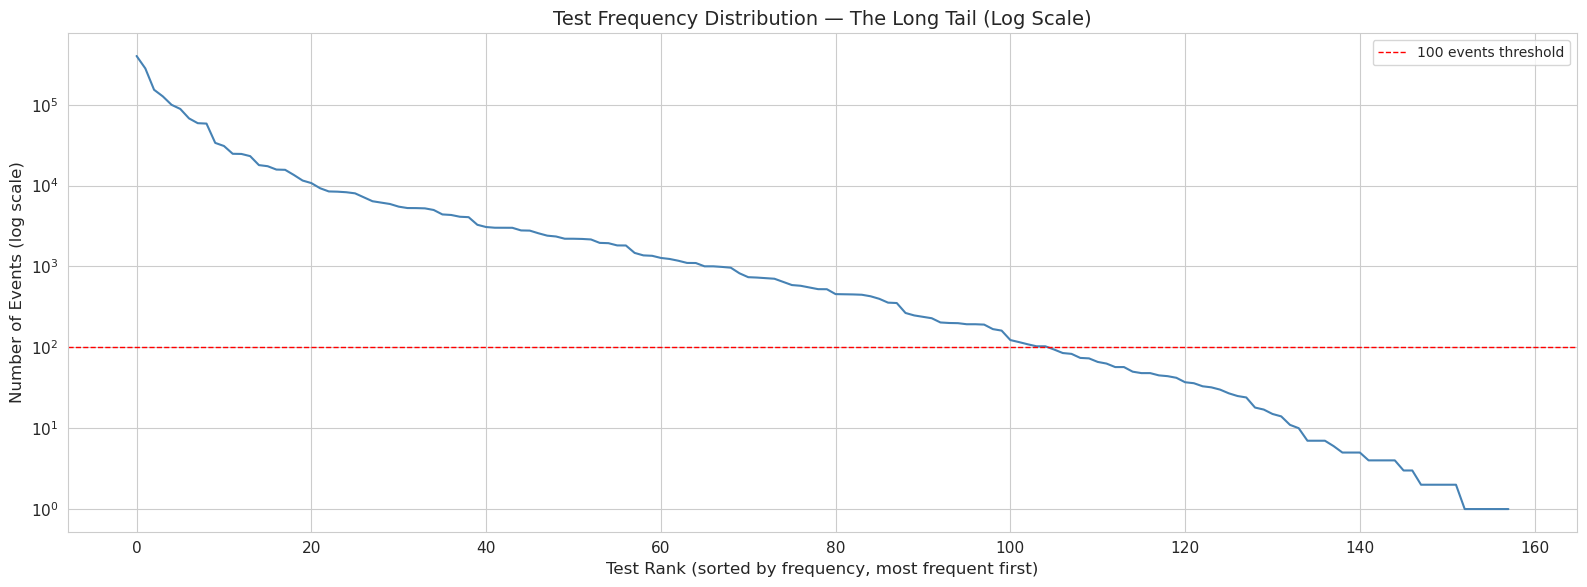


Tests with fewer than 100 events: 53 (33.5% of all tests)


In [6]:
# --- Test frequency distribution ---
test_counts = (
    micro_df.groupby('test_name')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f"Total unique test_name values: {test_counts.shape[0]}")
print("\nSummary statistics of test frequencies:")
print(test_counts['count'].describe().to_string())
print(f"\nTop 10 most frequent tests:")
print(test_counts.head(10).to_string(index=False))
print(f"\nBottom 10 least frequent tests:")
print(test_counts.tail(10).to_string(index=False))

# --- Line chart: Long Tail of test frequencies ---
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    range(len(test_counts)),
    test_counts['count'].values,
    color='steelblue',
    linewidth=1.5
)
ax.set_yscale('log')
ax.set_title('Test Frequency Distribution — The Long Tail (Log Scale)', fontsize=14)
ax.set_xlabel('Test Rank (sorted by frequency, most frequent first)', fontsize=12)
ax.set_ylabel('Number of Events (log scale)', fontsize=12)
ax.axhline(y=100, color='red', linestyle='--', linewidth=1, label='100 events threshold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

rare_tests = (test_counts['count'] < 100).sum()
print(f"\nTests with fewer than 100 events: {rare_tests} ({rare_tests / len(test_counts) * 100:.1f}% of all tests)")

## Section 4: Data Sparsity & Clinical Yield

In [7]:
total_events = len(micro_df)

# --- Yield Sparsity (Positivity Rate) ---
# Positive = org_name is not null AND does not contain 'NO GROWTH', 'CANCELLED', or 'VOID'
negative_keywords = ['NO GROWTH', 'CANCELLED', 'VOID']
has_org = micro_df['org_name'].notna()
is_negative_keyword = micro_df['org_name'].str.upper().str.contains(
    '|'.join(negative_keywords), na=False
)
positive_mask = has_org & ~is_negative_keyword
n_positive = positive_mask.sum()
yield_rate = n_positive / total_events * 100
print(f"=== Yield Sparsity (Positivity Rate) ===")
print(f"  Total microbiology events     : {total_events:,}")
print(f"  Events with organism isolated : {n_positive:,}")
print(f"  Positivity Rate               : {yield_rate:.2f}%")
print(f"  Yield Sparsity (negative rate): {100 - yield_rate:.2f}%")

# --- Susceptibility Sparsity ---
n_with_susceptibility = micro_df['ab_name'].notna().sum()
susceptibility_rate = n_with_susceptibility / total_events * 100
print(f"\n=== Susceptibility Sparsity ===")
print(f"  Events with antibiotic susceptibility data: {n_with_susceptibility:,}")
print(f"  Susceptibility Coverage Rate              : {susceptibility_rate:.2f}%")
print(f"  Susceptibility Sparsity                   : {100 - susceptibility_rate:.2f}%")

# --- Admission-level Sparsity ---
admissions_with_micro = micro_df['hadm_id'].nunique()
admission_coverage = admissions_with_micro / total_admissions * 100
print(f"\n=== Admission-level Sparsity ===")
print(f"  Total hospital admissions                  : {total_admissions:,}")
print(f"  Admissions with ≥1 microbiology event      : {admissions_with_micro:,}")
print(f"  Micro Coverage (% admissions with micro)   : {admission_coverage:.2f}%")
print(f"  Admission-level Sparsity                   : {100 - admission_coverage:.2f}%")

=== Yield Sparsity (Positivity Rate) ===
  Total microbiology events     : 1,759,881
  Events with organism isolated : 625,903
  Positivity Rate               : 35.57%
  Yield Sparsity (negative rate): 64.43%

=== Susceptibility Sparsity ===
  Events with antibiotic susceptibility data: 532,706
  Susceptibility Coverage Rate              : 30.27%
  Susceptibility Sparsity                   : 69.73%

=== Admission-level Sparsity ===
  Total hospital admissions                  : 546,028
  Admissions with ≥1 microbiology event      : 201,096
  Micro Coverage (% admissions with micro)   : 36.83%
  Admission-level Sparsity                   : 63.17%


## Section 5: The 7 Clinical Panels (RL Action Space)

Panel assignment distribution:
micro_panel
blood              442812
swab_and_screen    359629
urine              332745
respiratory        294001
other              184581
stool              123559
csf                 22554

Spec types mapped to 'other' panel (57 unique values):
spec_type_desc
MRSA SCREEN                                                 67930
SEROLOGY/BLOOD                                              18594
FLUID,OTHER                                                 18029
Rapid Respiratory Viral Screen & Culture                    16810
Staph aureus swab                                            9793
Blood (EBV)                                                  9020
Immunology (CMV)                                             6403
IMMUNOLOGY                                                   6204
Blood (CMV AB)                                               6060
Influenza A/B by DFA                                         4749
BONE MARROW - CYTOGENETICS                  

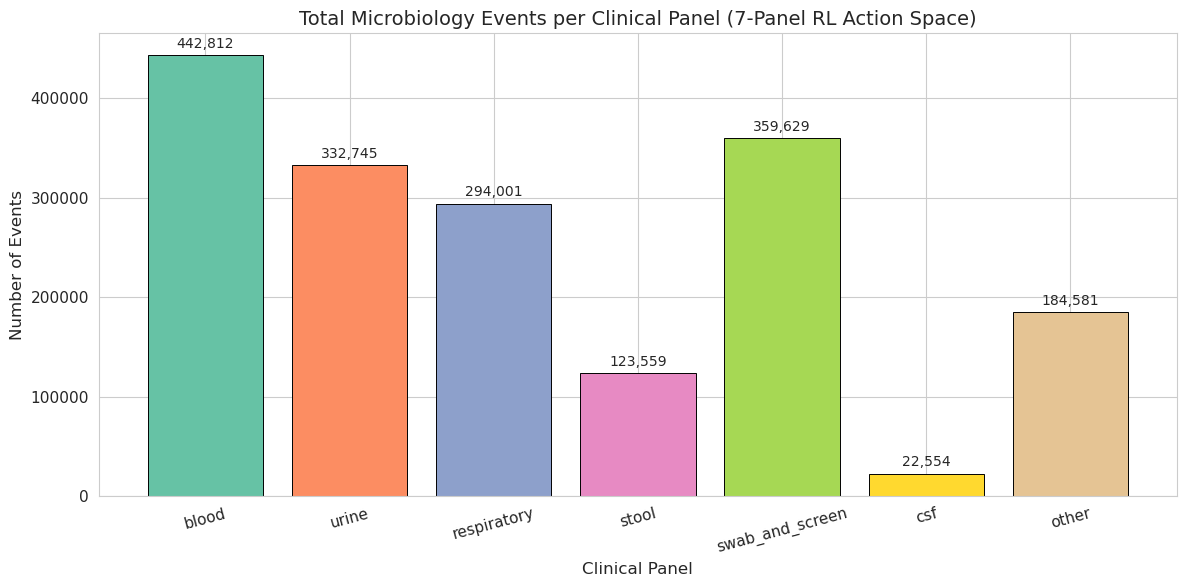


=== Panel Sparsity (% of all hospital admissions with ≥1 test per panel) ===
(Based on 546,028 total unique hospital admissions)

  blood               : 93,866 admissions  (17.19% coverage  |  82.81% sparsity)
  urine               : 100,546 admissions  (18.41% coverage  |  81.59% sparsity)
  respiratory         : 33,495 admissions  ( 6.13% coverage  |  93.87% sparsity)
  stool               : 36,679 admissions  ( 6.72% coverage  |  93.28% sparsity)
  swab_and_screen     : 40,758 admissions  ( 7.46% coverage  |  92.54% sparsity)
  csf                 :  5,737 admissions  ( 1.05% coverage  |  98.95% sparsity)
  other               : 84,298 admissions  (15.44% coverage  |  84.56% sparsity)


In [8]:
# --- Define mapping from spec_type_desc to 7 canonical RL panels ---
panel_mapping = {
    # Blood
    'BLOOD CULTURE': 'blood',
    'BLOOD CULTURE - SEROLOGY': 'blood',
    'BLOOD CULTURE ( MYCO/F LYTIC BOTTLE)': 'blood',
    'BLOOD CULTURE (POST-MORTEM)': 'blood',
    'BLOOD CULTURE (NEUROLOGICAL)': 'blood',
    'FLUID RECEIVED IN BLOOD CULTURE BOTTLES': 'blood',
    'SEROLOGY': 'blood',

    # Urine
    'URINE': 'urine',
    'URINE,KIDNEY': 'urine',
    'URINE,SUPRAPUBIC ASPIRATE': 'urine',
    'URINE,VOIDED': 'urine',
    'URINE,CYSTOSCOPY': 'urine',
    'URINE,FOLEY': 'urine',
    'URINE (ILEAL CONDUIT)': 'urine',

    # Stool
    'STOOL': 'stool',
    'FECES': 'stool',
    'RECTAL SWAB': 'stool',

    # Respiratory
    'BRONCHOALVEOLAR LAVAGE': 'respiratory',
    'BRONCHIAL WASHINGS': 'respiratory',
    'BRONCHIAL BRUSH': 'respiratory',
    'BRONCHIAL BRUSH - PROTECTED': 'respiratory',
    'SPUTUM': 'respiratory',
    'THROAT': 'respiratory',
    'THROAT CULTURE': 'respiratory',
    'THROAT FOR STREP': 'respiratory',
    'PLEURAL FLUID': 'respiratory',
    'NASOPHARYNGEAL SWAB': 'respiratory',
    'NASAL SWAB': 'respiratory',
    'Mini-BAL': 'respiratory',
    'TRANSTRACHEAL ASPIRATE': 'respiratory',
    'TRACHEAL ASPIRATE': 'respiratory',
    'BRONCHIAL ASPIRATE': 'respiratory',
    'ENDOTRACHEAL': 'respiratory',
    'ENDOTRACHEAL TUBE': 'respiratory',
    'SINUS ASPIRATE': 'respiratory',

    # Swab & Screen
    'WOUND CULTURE': 'swab_and_screen',
    'SWAB': 'swab_and_screen',
    'ABSCESS': 'swab_and_screen',
    'TISSUE': 'swab_and_screen',
    'SKIN SCRAPINGS': 'swab_and_screen',
    'EYE': 'swab_and_screen',
    'PERITONEAL FLUID': 'swab_and_screen',
    'BILE': 'swab_and_screen',
    'JOINT FLUID': 'swab_and_screen',
    'BONE MARROW': 'swab_and_screen',
    'CATHETER TIP-IV': 'swab_and_screen',
    'FOREIGN BODY': 'swab_and_screen',
    'NAIL CLIPPINGS': 'swab_and_screen',
    'HAIR': 'swab_and_screen',
    'PACEMAKER': 'swab_and_screen',

    # CSF
    'CEREBROSPINAL FLUID (CSF)': 'csf',
    'CSF;SPINAL FLUID': 'csf',
}

# Apply mapping; anything not explicitly listed goes to 'other'
micro_df['micro_panel'] = micro_df['spec_type_desc'].map(panel_mapping).fillna('other')

print("Panel assignment distribution:")
print(micro_df['micro_panel'].value_counts().to_string())

# Identify spec_type_desc values that were mapped to 'other' for transparency
other_specs = (
    micro_df[micro_df['micro_panel'] == 'other']['spec_type_desc']
    .value_counts()
)
print(f"\nSpec types mapped to 'other' panel ({len(other_specs)} unique values):")
print(other_specs.to_string())

# --- Bar chart: Total events per panel ---
panel_order = ['blood', 'urine', 'respiratory', 'stool', 'swab_and_screen', 'csf', 'other']
panel_counts = micro_df['micro_panel'].value_counts().reindex(panel_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('Set2', n_colors=len(panel_order))
bars = ax.bar(panel_counts.index, panel_counts.values, color=colors, edgecolor='black', linewidth=0.7)

# Annotate bars with counts
for bar, count in zip(bars, panel_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(panel_counts.values) * 0.01,
        f'{count:,}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Total Microbiology Events per Clinical Panel (7-Panel RL Action Space)', fontsize=14)
ax.set_xlabel('Clinical Panel', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
plt.show()

# --- Panel Sparsity: % of all admissions with ≥1 test from each panel ---
print("\n=== Panel Sparsity (% of all hospital admissions with ≥1 test per panel) ===")
print(f"(Based on {total_admissions:,} total unique hospital admissions)\n")

for panel in panel_order:
    panel_hadm = micro_df[micro_df['micro_panel'] == panel]['hadm_id'].nunique()
    coverage = panel_hadm / total_admissions * 100
    sparsity = 100 - coverage
    print(
        f"  {panel:<20s}: {panel_hadm:>6,} admissions  "
        f"({coverage:5.2f}% coverage  |  {sparsity:5.2f}% sparsity)"
    )

## Section 6: `other` Panel Deep-Dive

The `other` panel collects all `spec_type_desc` values that don't map to the six named panels. Before treating it as a monolithic catch-all panel we break it down into natural clinical sub-categories to decide which, if any, deserve their own dedicated RL panel.

In [ ]:
# --- 6a: other panel breakdown by sub-category ---

other_df = micro_df[micro_df['micro_panel'] == 'other'].copy()

# Sub-category definitions
subcategory_map = {
    'Serology / immunology': [
        'SEROLOGY/BLOOD', 'Blood (EBV)', 'Blood (CMV AB)', 'Blood (Toxo)',
        'Blood (LYME)', 'IMMUNOLOGY', 'Immunology (CMV)',
    ],
    'Fluid / wound / tissue': [
        'FLUID,OTHER', 'DIALYSIS FLUID', 'ASPIRATE', 'BIOPSY',
        'FOOT CULTURE', 'Foreign Body - Sonication Culture',
        'PROSTHETIC JOINT FLUID', 'FLUID WOUND', 'EAR', 'ANORECTAL/VAGINAL',
        'CORNEAL EYE SCRAPINGS', 'NAIL SCRAPINGS',
    ],
    'Screens': [
        'MRSA SCREEN', 'Staph aureus swab', 'CRE Screen',
        'Swab R/O Yeast Screen', 'Infection Control Yeast',
    ],
    'Rapid respiratory / viral': [
        'Rapid Respiratory Viral Screen & Culture',
        'Influenza A/B by DFA',
        'RAPID RESPIRATORY VIRAL ANTIGEN TEST',
        'DIRECT ANTIGEN TEST FOR VARICELLA-ZOSTER VIRUS',
        'Direct Antigen Test for Herpes Simplex Virus Types 1 & 2',
        'VIRAL CULTURE', 'VIRAL CULTURE: R/O CYTOMEGALOVIRUS',
        'VIRAL CULTURE:R/O HERPES SIMPLEX VIRUS', 'VARICELLA-ZOSTER CULTURE',
    ],
    'Cytogenetics / chromosomal': [
        'BONE MARROW - CYTOGENETICS', 'NEOPLASTIC BLOOD',
        'PERIPHERAL BLOOD LYMPHOCYTES', 'AMNIOTIC FLUID',
        'CHORIONIC VILLUS SAMPLE', 'Touch Prep/Sections',
    ],
}

# Assign sub-categories
def assign_subcat(spec):
    for subcat, specs in subcategory_map.items():
        if spec in specs:
            return subcat
    return 'Other / misc'

other_df['sub_category'] = other_df['spec_type_desc'].apply(assign_subcat)

print("=== 6a: 'other' panel sub-category breakdown ===\n")
subcat_summary = []
for subcat in list(subcategory_map.keys()) + ['Other / misc']:
    rows = other_df[other_df['sub_category'] == subcat]
    n_specs = rows['spec_type_desc'].nunique()
    n_events = len(rows)
    n_hadm = rows['hadm_id'].nunique()
    pct = n_hadm / total_admissions * 100
    subcat_summary.append({
        'sub_category': subcat,
        'n_spec_types': n_specs,
        'event_count': n_events,
        'unique_admissions': n_hadm,
        'pct_admissions': pct,
    })
    print(f"  {subcat}")
    print(f"    Unique spec_type_desc : {n_specs:,}")
    print(f"    Total events          : {n_events:,}")
    print(f"    Unique admissions     : {n_hadm:,}  ({pct:.2f}% of all admissions)")
    print()

import pandas as pd
subcat_df = pd.DataFrame(subcat_summary)


In [ ]:
# --- 6b: Horizontal bar chart — event count per other sub-category ---
import matplotlib.pyplot as plt
import seaborn as sns

subcat_df_sorted = subcat_df.sort_values('event_count', ascending=True)
palette = sns.color_palette('tab10', n_colors=len(subcat_df_sorted))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    subcat_df_sorted['sub_category'],
    subcat_df_sorted['event_count'],
    color=palette,
    edgecolor='black',
    linewidth=0.6,
)
for bar, val in zip(bars, subcat_df_sorted['event_count']):
    ax.text(bar.get_width() + max(subcat_df_sorted['event_count']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title("Event Count per 'other' Panel Sub-Category", fontsize=14)
ax.set_xlabel("Number of Events", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# --- 6c: Decision table — should sub-category become its own panel? ---
print("=== 6c: Decision Table — Should sub-category become its own panel? ===\n")
print(f"{'Sub-category':<35} {'Events':>8} {'Admissions':>10} {'% Adm':>7}  Recommendation")
print("-" * 90)
for row in subcat_summary:
    rec = ">1% admissions → own panel" if row['pct_admissions'] >= 1.0 else "<1% → keep in other"
    print(f"  {row['sub_category']:<33} {row['event_count']:>8,} {row['unique_admissions']:>10,} "
          f"{row['pct_admissions']:>6.2f}%  {rec}")


## Section 7: Organism Analysis

Understanding which organisms are most frequently cultured — overall and per panel — is critical for deciding how much clinical signal each panel carries and for designing the text representation fed to the language model.

In [ ]:
# --- 7a: Top 30 organisms overall (by event count) ---
top30_orgs = (
    micro_df.dropna(subset=['org_name'])
    .groupby('org_name')
    .size()
    .sort_values(ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(14, 9))
top30_orgs.sort_values().plot.barh(ax=ax, color=sns.color_palette('viridis', 30), edgecolor='black', linewidth=0.5)
ax.set_title('Top 30 Organisms by Event Count (All Panels)', fontsize=14)
ax.set_xlabel('Number of Events', fontsize=12)
ax.set_ylabel('Organism', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# --- 7b: Top 10 organisms per panel (2×3 grid, excludes 'other') ---
panels_for_grid = ['blood', 'urine', 'respiratory', 'stool', 'swab_and_screen', 'csf']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, panel in enumerate(panels_for_grid):
    panel_data = micro_df[micro_df['micro_panel'] == panel]
    total_panel = len(panel_data)
    positivity_rate = panel_data['org_name'].notna().mean() * 100

    top10 = (
        panel_data.dropna(subset=['org_name'])
        .groupby('org_name')
        .size()
        .sort_values(ascending=False)
        .head(10)
    )
    ax = axes[idx]
    if len(top10) > 0:
        top10.sort_values().plot.barh(
            ax=ax,
            color=sns.color_palette('Set2', len(top10)),
            edgecolor='black', linewidth=0.5,
        )
    ax.set_title(f'{panel}\n(positivity rate: {positivity_rate:.1f}%)', fontsize=11)
    ax.set_xlabel('Events', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 Organisms per Panel', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# --- 7c: Positivity rate per panel ---
panel_order = ['blood', 'urine', 'respiratory', 'stool', 'swab_and_screen', 'csf', 'other']
positivity_data = []

print("=== 7c: Positivity Rate per Panel ===\n")
print(f"{'Panel':<20} {'Total Events':>13} {'Positive Events':>16} {'Positivity Rate':>16}")
print("-" * 70)
for panel in panel_order:
    p_df = micro_df[micro_df['micro_panel'] == panel]
    total = len(p_df)
    positive = p_df['org_name'].notna().sum()
    rate = positive / total * 100 if total > 0 else 0
    positivity_data.append({'panel': panel, 'total': total, 'positive': positive, 'rate': rate})
    print(f"  {panel:<18} {total:>13,} {positive:>16,} {rate:>15.1f}%")

pos_df = pd.DataFrame(positivity_data).sort_values('rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('RdYlGn', n_colors=len(pos_df))
bars = ax.bar(pos_df['panel'], pos_df['rate'], color=colors, edgecolor='black', linewidth=0.7)
for bar, val in zip(bars, pos_df['rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Positivity Rate per Panel (% of events with organism identified)', fontsize=13)
ax.set_xlabel('Panel', fontsize=12)
ax.set_ylabel('Positivity Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.tick_params(axis='x', labelrotation=15)
plt.tight_layout()
plt.show()


In [ ]:
# --- 7d: Most resistant organisms ---
# Among rows with susceptibility data, compute % R per organism (min 50 tests)
ab_df = micro_df.dropna(subset=['ab_name', 'interpretation'])
org_resist = (
    ab_df
    .groupby('org_name')
    .agg(
        total_susceptibility_tests=('interpretation', 'count'),
        n_resistant=('interpretation', lambda x: (x == 'R').sum()),
    )
    .reset_index()
)
org_resist = org_resist[org_resist['total_susceptibility_tests'] >= 50].copy()
org_resist['resistance_rate_pct'] = (
    org_resist['n_resistant'] / org_resist['total_susceptibility_tests'] * 100
)
org_resist = org_resist.sort_values('resistance_rate_pct', ascending=False).head(20)

print("=== 7d: Top 20 Most Resistant Organisms (min 50 susceptibility tests) ===\n")
print(f"{'Organism':<50} {'Tests':>7} {'Resistant':>10} {'Resistance %':>13}")
print("-" * 85)
for _, row in org_resist.iterrows():
    print(f"  {row['org_name']:<48} {row['total_susceptibility_tests']:>7,} "
          f"{row['n_resistant']:>10,} {row['resistance_rate_pct']:>12.1f}%")


## Section 8: Antibiotic Resistance Profile

Antibiotic resistance patterns reveal the clinical complexity captured in the microbiology data and guide decisions about which antibiotic-level features to include in the text representation.

In [ ]:
# --- 8a: Top 20 antibiotics by frequency ---
top20_ab = (
    micro_df.dropna(subset=['ab_name'])
    .groupby('ab_name')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 7))
top20_ab.sort_values().plot.barh(
    ax=ax,
    color=sns.color_palette('Blues_r', len(top20_ab)),
    edgecolor='black', linewidth=0.5,
)
ax.set_title('Top 20 Antibiotics by Test Frequency', fontsize=14)
ax.set_xlabel('Number of Susceptibility Tests', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# --- 8b: Resistance rate per antibiotic (stacked bar: %R, %I, %S) ---
ab_interp = micro_df.dropna(subset=['ab_name', 'interpretation']).copy()

ab_counts = ab_interp.groupby('ab_name').size()
ab_qualified = ab_counts[ab_counts >= 100].index

ab_pct = (
    ab_interp[ab_interp['ab_name'].isin(ab_qualified)]
    .groupby(['ab_name', 'interpretation'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to percentage
ab_pct = ab_pct.div(ab_pct.sum(axis=1), axis=0) * 100

# Keep R, I, S columns only
for col in ['R', 'I', 'S']:
    if col not in ab_pct.columns:
        ab_pct[col] = 0
ab_pct = ab_pct[['R', 'I', 'S']]

# Sort by resistance rate descending, keep top 25
ab_pct = ab_pct.sort_values('R', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(14, 9))
ab_pct.sort_values('R').plot.barh(
    stacked=True,
    ax=ax,
    color=['#d73027', '#fee090', '#4575b4'],
    edgecolor='black',
    linewidth=0.4,
)
ax.set_title('Resistance Profile per Antibiotic (≥100 tests) — Top 25 by Resistance Rate', fontsize=13)
ax.set_xlabel('Percentage of Tests (%)', fontsize=12)
ax.legend(['Resistant (R)', 'Intermediate (I)', 'Susceptible (S)'], loc='lower right')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()


In [ ]:
# --- 8c: Resistance heatmap — top 15 organisms × top 15 antibiotics ---
import numpy as np

ab_df_clean = micro_df.dropna(subset=['org_name', 'ab_name', 'interpretation']).copy()

top15_orgs = ab_df_clean.groupby('org_name').size().sort_values(ascending=False).head(15).index
top15_abs  = ab_df_clean.groupby('ab_name').size().sort_values(ascending=False).head(15).index

heat_df = ab_df_clean[
    ab_df_clean['org_name'].isin(top15_orgs) &
    ab_df_clean['ab_name'].isin(top15_abs)
]

# Compute % R and test count for each cell
pivot_r = heat_df[heat_df['interpretation'] == 'R'].groupby(['org_name', 'ab_name']).size().unstack(fill_value=0)
pivot_total = heat_df.groupby(['org_name', 'ab_name']).size().unstack(fill_value=0)

pivot_r = pivot_r.reindex(index=top15_orgs, columns=top15_abs, fill_value=0)
pivot_total = pivot_total.reindex(index=top15_orgs, columns=top15_abs, fill_value=0)

pivot_pct = np.where(pivot_total >= 10, pivot_r / pivot_total.replace(0, np.nan) * 100, np.nan)
pivot_pct_df = pd.DataFrame(pivot_pct, index=top15_orgs, columns=top15_abs)

annot_df = pivot_pct_df.applymap(lambda v: f'{v:.0f}%' if not np.isnan(v) else 'n<10')

fig, ax = plt.subplots(figsize=(16, 10))
mask = pivot_pct_df.isna()
sns.heatmap(
    pivot_pct_df,
    annot=annot_df,
    fmt='',
    cmap='Reds',
    mask=mask,
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': '% Resistant (R)'},
)
# Grey out masked cells
sns.heatmap(
    pivot_pct_df.isna().astype(float),
    cmap=['#cccccc', '#cccccc'],
    mask=~mask,
    linewidths=0.5,
    ax=ax,
    cbar=False,
    annot=annot_df,
    fmt='',
)
ax.set_title('Resistance Heatmap: Top 15 Organisms × Top 15 Antibiotics (% R; grey = <10 tests)', fontsize=13)
ax.set_xlabel('Antibiotic', fontsize=11)
ax.set_ylabel('Organism', fontsize=11)
ax.tick_params(axis='x', labelrotation=45)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()


## Section 9: Admission-Level Temporal Analysis

Timing patterns reveal *when* microbiology is ordered relative to admission, which affects the feature engineering strategy: early cultures (within 24h) likely reflect triage decisions while late cultures reflect evolving clinical needs.

In [ ]:
# --- 9a: Distribution of microbiology event count per admission ---
events_per_adm = micro_df.groupby('hadm_id').size()

print("=== 9a: Events per Admission (among admissions with ≥1 micro event) ===")
print(f"  Median         : {events_per_adm.median():.0f}")
print(f"  Mean           : {events_per_adm.mean():.1f}")
print(f"  90th percentile: {events_per_adm.quantile(0.90):.0f}")
print(f"  99th percentile: {events_per_adm.quantile(0.99):.0f}")
print(f"  Max            : {events_per_adm.max():,}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(events_per_adm, bins=50, color=sns.color_palette('Set1')[0], edgecolor='black', linewidth=0.4)
ax.set_yscale('log')
ax.set_title('Distribution of Microbiology Event Count per Admission (log y-axis)', fontsize=13)
ax.set_xlabel('Number of Microbiology Events', fontsize=12)
ax.set_ylabel('Number of Admissions (log scale)', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# --- 9b: Time from admission to first microbiology event ---
# adm_df is loaded in Cell 2; micro_df has 'charttime' column
adm_times = adm_df[['hadm_id', 'admittime']].copy()
adm_times['admittime'] = pd.to_datetime(adm_times['admittime'])

micro_timed = micro_df[['hadm_id', 'charttime']].copy()
micro_timed['charttime'] = pd.to_datetime(micro_timed['charttime'])

# First event per admission
first_event = micro_timed.dropna(subset=['charttime']).sort_values('charttime').groupby('hadm_id').first().reset_index()
first_event = first_event.merge(adm_times, on='hadm_id', how='inner')
first_event['hours_to_first'] = (first_event['charttime'] - first_event['admittime']).dt.total_seconds() / 3600

# Keep only plausible range (−12h to 7 days)
first_event_filtered = first_event[(first_event['hours_to_first'] >= -12) & (first_event['hours_to_first'] <= 168)]

pct_24h = (first_event_filtered['hours_to_first'] <= 24).mean() * 100
pct_48h = (first_event_filtered['hours_to_first'] <= 48).mean() * 100
median_h = first_event_filtered['hours_to_first'].median()

print("=== 9b: Time from Admission to First Microbiology Event ===")
print(f"  Median hours to first event : {median_h:.1f}h")
print(f"  Within 24h                  : {pct_24h:.1f}%")
print(f"  Within 48h                  : {pct_48h:.1f}%")

fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(
    first_event_filtered['hours_to_first'].clip(0, 72),
    bins=range(0, 74, 2),
    color=sns.color_palette('Set2')[1],
    edgecolor='black', linewidth=0.4,
)
ax.set_title('Time from Admission to First Microbiology Event (0–72h, 2h bins)', fontsize=13)
ax.set_xlabel('Hours from Admission', fontsize=12)
ax.set_ylabel('Number of Admissions', fontsize=12)
ax.axvline(24, color='red', linestyle='--', label='24h')
ax.axvline(48, color='orange', linestyle='--', label='48h')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
# --- 9c: Positive culture rate by time bucket ---
micro_timed2 = micro_df[['hadm_id', 'charttime', 'org_name']].copy()
micro_timed2['charttime'] = pd.to_datetime(micro_timed2['charttime'])
micro_timed2 = micro_timed2.merge(adm_times, on='hadm_id', how='inner')
micro_timed2['hours_since_adm'] = (micro_timed2['charttime'] - micro_timed2['admittime']).dt.total_seconds() / 3600
micro_timed2 = micro_timed2[(micro_timed2['hours_since_adm'] >= 0) & (micro_timed2['hours_since_adm'] <= 168)]

def bucket(h):
    if h <= 6:   return '0–6h'
    elif h <= 24: return '6–24h'
    elif h <= 48: return '24–48h'
    elif h <= 72: return '48–72h'
    else:         return '>72h'

bucket_order = ['0–6h', '6–24h', '24–48h', '48–72h', '>72h']
micro_timed2['time_bucket'] = micro_timed2['hours_since_adm'].apply(bucket)
micro_timed2['is_positive'] = micro_timed2['org_name'].notna()

bucket_rates = (
    micro_timed2.groupby('time_bucket')['is_positive']
    .agg(['mean', 'count'])
    .reindex(bucket_order)
)
bucket_rates['positivity_rate_pct'] = bucket_rates['mean'] * 100

print("=== 9c: Positivity Rate by Time Bucket ===")
print(f"{'Bucket':<12} {'Events':>9} {'Positivity %':>14}")
print("-" * 38)
for bucket_name, row in bucket_rates.iterrows():
    print(f"  {bucket_name:<10} {int(row['count']):>9,} {row['positivity_rate_pct']:>13.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(bucket_order, bucket_rates['positivity_rate_pct'], marker='o', linewidth=2,
        color=sns.color_palette('Set1')[2], markersize=8)
ax.set_title('Positive Culture Rate by Time Since Admission', fontsize=13)
ax.set_xlabel('Time Bucket (hours since admission)', fontsize=12)
ax.set_ylabel('Positivity Rate (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Section 10: Panel Co-occurrence

Do patients receive multiple panel types in a single admission? Co-occurrence patterns inform whether panels should be encoded independently or jointly, and reveal clinical workflows (e.g., blood + urine cultures ordered together).

In [ ]:
# --- 10a: % of admissions with 1, 2, 3+ panels ---
adm_panels = (
    micro_df.groupby('hadm_id')['micro_panel']
    .apply(set)
    .reset_index()
)
adm_panels['n_panels'] = adm_panels['micro_panel'].apply(len)

total_micro_adm = len(adm_panels)
print("=== 10a: Panel Count Distribution per Admission ===")
for n in sorted(adm_panels['n_panels'].unique()):
    cnt = (adm_panels['n_panels'] == n).sum()
    pct = cnt / total_micro_adm * 100
    label = f"{n} panel{'s' if n > 1 else ''}"
    print(f"  Exactly {label:<12}: {cnt:>6,}  ({pct:.1f}%)")

# Summary
pct_1 = (adm_panels['n_panels'] == 1).mean() * 100
pct_2 = (adm_panels['n_panels'] == 2).mean() * 100
pct_3plus = (adm_panels['n_panels'] >= 3).mean() * 100
print(f"\n  Summary:")
print(f"    1 panel only : {pct_1:.1f}%")
print(f"    2 panels     : {pct_2:.1f}%")
print(f"    3+ panels    : {pct_3plus:.1f}%")


In [ ]:
# --- 10b: Panel co-occurrence heatmap ---
import numpy as np
panel_order_all = ['blood', 'urine', 'respiratory', 'stool', 'swab_and_screen', 'csf', 'other']

cooccur = pd.DataFrame(0, index=panel_order_all, columns=panel_order_all)
for panels_set in adm_panels['micro_panel']:
    panels_list = [p for p in panel_order_all if p in panels_set]
    for p1 in panels_list:
        for p2 in panels_list:
            cooccur.loc[p1, p2] += 1

# log1p for color scale
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    np.log1p(cooccur),
    annot=cooccur.applymap(lambda v: f'{v:,}'),
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'log(1 + admissions)'},
)
ax.set_title('Panel Co-occurrence Matrix (cell = # admissions with both panels; log color scale)', fontsize=12)
ax.tick_params(axis='x', labelrotation=30)
ax.tick_params(axis='y', labelrotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# --- 10c: Top 10 panel combinations ---
from collections import Counter

combo_counter = Counter(
    frozenset(s) for s in adm_panels['micro_panel']
)
top10_combos = combo_counter.most_common(10)

print("=== 10c: Top 10 Panel Combinations (by admission count) ===\n")
print(f"{'Rank':<5} {'Combination':<50} {'Admissions':>12}")
print("-" * 70)
for rank, (combo, cnt) in enumerate(top10_combos, 1):
    combo_str = ' + '.join(sorted(combo))
    print(f"  {rank:<3} {combo_str:<50} {cnt:>12,}")


## Section 11: Feature Engineering Implications

This section synthesises the EDA findings into actionable recommendations for panel structure and text representation. For each panel we compute coverage, positivity rate, and susceptibility coverage, then emit a signal-strength label that guides embedding design.

In [ ]:
# --- Section 11: Feature Engineering Implications ---
panel_order_all = ['blood', 'urine', 'respiratory', 'stool', 'swab_and_screen', 'csf', 'other']

print("=" * 100)
print("FEATURE ENGINEERING IMPLICATIONS — PANEL SIGNAL SUMMARY")
print("=" * 100)
print()
header = (f"{'Panel':<20} {'Events':>8} {'Admissions':>11} {'Coverage%':>10} "
          f"{'Pos%':>7} {'MedEvPos':>9} {'Susc%':>7}  Signal")
print(header)
print("-" * 100)

for panel in panel_order_all:
    p_df = micro_df[micro_df['micro_panel'] == panel]
    n_events = len(p_df)
    n_adm = p_df['hadm_id'].nunique()
    coverage = n_adm / total_admissions * 100
    pos_rate = p_df['org_name'].notna().mean() * 100
    pos_adm = p_df[p_df['org_name'].notna()]['hadm_id'].unique()
    if len(pos_adm) > 0:
        med_ev_pos = (
            p_df[p_df['org_name'].notna()]
            .groupby('hadm_id')
            .size()
            .median()
        )
    else:
        med_ev_pos = 0
    # % of positive admissions with susceptibility data
    susc_adm = p_df[p_df['ab_name'].notna()]['hadm_id'].nunique()
    pct_susc = susc_adm / max(len(pos_adm), 1) * 100

    if coverage > 5 and pos_rate > 20:
        signal = "HIGH SIGNAL — own embedding"
    elif coverage > 2:
        signal = "MEDIUM SIGNAL — own embedding"
    else:
        signal = "LOW SIGNAL — consider merging"

    print(f"  {panel:<18} {n_events:>8,} {n_adm:>11,} {coverage:>9.2f}% "
          f"{pos_rate:>6.1f}% {med_ev_pos:>9.1f} {pct_susc:>6.1f}%  {signal}")

print()
print("=" * 100)
print("'OTHER' PANEL SUB-CATEGORY IMPLICATIONS")
print("=" * 100)
print()

# Reuse other_df and subcat_summary from Section 6
print(f"{'Sub-category':<35} {'Events':>8} {'Admissions':>11} {'Coverage%':>10} "
      f"{'Pos%':>7}  Signal")
print("-" * 90)
for row in subcat_summary:
    subcat = row['sub_category']
    rows_sc = other_df[other_df['sub_category'] == subcat]
    n_events = row['event_count']
    n_adm = row['unique_admissions']
    coverage = row['pct_admissions']
    pos_rate = rows_sc['org_name'].notna().mean() * 100 if n_events > 0 else 0

    if coverage > 5 and pos_rate > 20:
        signal = "HIGH SIGNAL — own embedding"
    elif coverage > 2:
        signal = "MEDIUM SIGNAL — own embedding"
    else:
        signal = "LOW SIGNAL — consider merging"

    print(f"  {subcat:<33} {n_events:>8,} {n_adm:>11,} {coverage:>9.2f}% "
          f"{pos_rate:>6.1f}%  {signal}")

print()
print("Done — see above for panel embedding recommendations.")
